# TRIDIS v2 + BigLAM YOLO — Segmented HTR Pipeline

> **GPU:** Runs on Colab free tier. **Recommended: T4 (16 GB).**
> In Colab: *Runtime → Change runtime type → T4.*
> Combined VRAM: ~5-6 GB (TRIDIS ~2-3 GB + YOLO ~2-3 GB), fits comfortably on T4.

This notebook transcribes evaluation subset pages using a **two-stage segmented
pipeline**:

1. **[BigLAM YOLO](https://huggingface.co/biglam/medieval-manuscript-yolov11)** detects
   text line regions on each full manuscript page.
2. **[TRIDIS v2](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts)**
   transcribes each cropped text line individually.

This follows the YOLO→TrOCR pipeline pattern proven by
[HTRflow](https://huggingface.co/blog/Gabriel/htrflow) (0.75% CER on similar
medieval manuscript data).

### Why segmentation matters

TRIDIS v2 is a **line-level** model — its ViT encoder resizes all input to **384×384
pixels**
([preprocessor_config.json](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts/blob/main/preprocessor_config.json)).
When fed a full manuscript page (e.g. 2000×3000 pixels), the entire page gets crushed
into that 384×384 grid, making individual characters unreadable. By first detecting
text lines with YOLO and cropping each line, the 384×384 resize preserves far more
detail per line — exactly how the model was trained.

### TRIDIS v2

- **Architecture**: Fine-tuned from
  [TrOCR-large-handwritten](https://huggingface.co/microsoft/trocr-large-handwritten)
  with a **medievalized RoBERTa** decoder, replacing the modern-English GPT-2 head with
  one trained on medieval orthography
  ([paper §3.2](https://arxiv.org/abs/2503.22714)).
- **Training data**: ~245K lines from **6 medieval corpora** spanning 4 languages —
  CODEA (Old Spanish, 11th–16th c.), e-NDP (French/Latin), Himanis (French/Latin),
  Königsfelden (German), and Monumenta Luxemburgensia (Latin) — plus ~400K synthetic
  GAN-generated lines for data augmentation
  ([paper §2](https://arxiv.org/abs/2503.22714)).
- **Design goal**: Purpose-built for medieval **documentary** manuscripts (charters,
  registers, legal proceedings) rather than literary or modern texts.

### BigLAM YOLO

- **Architecture**: YOLOv11-Large fine-tuned on
  [CATMuS medieval segmentation](https://huggingface.co/datasets/CATMuS/medieval-segmentation)
  with [SegmOnto](https://segmonto.github.io/) vocabulary for document layout analysis.
- **Key classes**: `DefaultLine` (mAP50: 0.763), `HeadingLine` (mAP50: 0.383) — these
  are the text line classes we use for cropping.
- **Performance**: 0.684 mAP50 overall across all SegmOnto classes; strong on text
  lines and decorations, weaker on marginal elements.

### Dual-model comparison

| Property | TRIDIS v2 | BigLAM YOLO |
|----------|-----------|-------------|
| HuggingFace ID | `magistermilitum/tridis_v2_HTR_historical_manuscripts` | `biglam/medieval-manuscript-yolov11` |
| Task | Line-level HTR | Text line detection |
| Architecture | TrOCR-large (ViT + RoBERTa) | YOLOv11-Large |
| Parameters | ~558M | ~25M |
| VRAM | ~2-3 GB | ~2-3 GB |
| Input | 384×384 line crop | Full-res page image |
| Output | Transcribed text | Bounding boxes + classes |

### Architecture: TrOCR

TrOCR ([Li et al. 2023](https://arxiv.org/abs/2109.10282)) combines a
**Vision Transformer (ViT)** encoder with a text decoder:
- The ViT encoder processes the input image into patch embeddings (384×384 input,
  [preprocessor config](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts/blob/main/preprocessor_config.json))
- The decoder autoregressively generates text tokens
- No explicit CTC or attention alignment — purely sequence-to-sequence

This architecture excels at line-level recognition but lacks the spatial reasoning
needed for full-page layout understanding — hence the need for YOLO segmentation.

## 1. Setup & Data Access

We mount Google Drive so the notebook can read the evaluation images that have been
pre-uploaded to `MyDrive/paleo-ocr/subset_images/`. Four path variables control where
inputs are read from and where outputs are written:

- **`DRIVE_BASE`** — root of the paleo-ocr project on Drive.
- **`IMAGES_DIR`** — folder containing the manuscript page images.
- **`MANIFEST_PATH`** — JSON file listing every page to transcribe (page ID,
  canonical file name, document metadata).
- **`OUTPUT_DIR`** — where raw transcription `.txt` files are saved (one per page).

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Cache HuggingFace models on local storage (wiped when session ends, saves Drive space)
os.environ['HF_HOME'] = '/content/.hf_cache'

# Authenticate with HuggingFace for faster downloads (optional)
try:
    from google.colab import userdata
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
    print('HF_TOKEN loaded from Colab secrets')
except (ImportError, userdata.SecretNotFoundError):
    print('HF_TOKEN not found — downloads will be unauthenticated (slower)')

DRIVE_BASE = '/content/drive/MyDrive/paleo-ocr'
IMAGES_DIR = f'{DRIVE_BASE}/subset_images'
MANIFEST_PATH = f'{DRIVE_BASE}/evaluation_subset.json'
OUTPUT_DIR = f'{DRIVE_BASE}/data/results/tridis_v2/raw'

## 2. Install Dependencies

| Package | Purpose |
|---------|---------|
| `transformers` | Model and processor classes |
| `torch` | Tensor operations, GPU inference |
| `accelerate` | General HuggingFace utilities |
| `pillow` | Image loading and conversion |
| `ultralytics` | YOLOv11 object detection for text line segmentation |

**Config patching:** TRIDIS v2's model repository has a config/checkpoint mismatch
(`vocab_size=8000` in config vs 50265-dim `embed_tokens` in weights, and
`max_position_embeddings=514` vs actual 512). We patch the config and manually
fix the embedding weights after loading — see the model loading cell for details.

TRIDIS uses standard HuggingFace classes. BigLAM YOLO uses ultralytics for
YOLOv11 inference, with model weights downloaded via `huggingface_hub`
(a transitive dependency of `transformers`).

In [8]:
!pip install -q transformers torch accelerate pillow ultralytics

## 3. Load Manifest & Prepare Output

We load the evaluation manifest (which lists all pages to transcribe) and create the
output directory. The manifest is a JSON array of objects, each with `page_id`,
`canonical_name` (image filename), and document metadata.

**Resumability**: any page whose output file already exists and is non-empty will be
skipped in the transcription loop, so the notebook can be re-run after interruptions
without re-processing.

In [13]:
import json, os
from pathlib import Path
from PIL import Image
import torch

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)
print(f'Loaded {len(manifest)} pages')

# >>> TRIAL RUN: process only CODEA-0143 (2 pages) — remove this line for full evaluation
#manifest = [e for e in manifest if e['doc_id'] == 'CODEA-0143']
print(f'  Filtered to {len(manifest)} pages (trial run: CODEA-0143 only)')

os.makedirs(OUTPUT_DIR, exist_ok=True)

Loaded 60 pages
  Filtered to 60 pages (trial run: CODEA-0143 only)


## 4. Load Models

We load two models — BigLAM YOLO for line detection and TRIDIS v2 for transcription.

### Stage 1: BigLAM YOLO (line segmentation)

- **Source**: [`biglam/medieval-manuscript-yolov11`](https://huggingface.co/biglam/medieval-manuscript-yolov11)
  — YOLOv11-Large trained on [CATMuS medieval segmentation](https://huggingface.co/datasets/CATMuS/medieval-segmentation).
- **SegmOnto vocabulary**: The model detects layout elements using standardized
  [SegmOnto](https://segmonto.github.io/) class names. We filter to text line classes only.
- **Class filtering**: We resolve class IDs by **name** at runtime (not hardcoded integer
  IDs) — this is robust to class reordering across model versions.

**Text line classes used for cropping:**

| Class | mAP50 | Description |
|-------|-------|-------------|
| `DefaultLine` | 0.763 | Standard text lines (body text) |
| `HeadingLine` | 0.383 | Section headings and titles |

**Confidence threshold**: `0.3` — low enough to capture faint or partially visible lines
in degraded manuscripts, while filtering obvious false positives. The model's precision
is high enough at this threshold that most detections are genuine text lines.

### Stage 2: TRIDIS v2 (line-level HTR)

**Model loading** (matches the
[official model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts)):

- **`TrOCRProcessor`** — handles image preprocessing: resize to **384×384**, rescale
  to [0,1], normalize with mean/std = 0.5
  ([preprocessor_config.json](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts/blob/main/preprocessor_config.json)).
  With line crops instead of full pages, the 384×384 resize preserves far more detail
  per character — exactly how the model was trained.
- **`VisionEncoderDecoderModel`** — the HuggingFace class for encoder-decoder vision
  models. Required because TRIDIS combines a ViT encoder with a separate text decoder.
- **Config patching** — the model repository has config/checkpoint mismatches from the
  fine-tuning process. We patch three fields before loading:

  | Field | Config value | Correct value | Why |
  |-------|-------------|---------------|-----|
  | `decoder.max_position_embeddings` | 514 | 512 | Checkpoint `embed_positions` is [514, 1024] = 512 + 2 offset |
  | `decoder.tie_word_embeddings` | true | false | `embed_tokens` (50265) and `output_projection` (8000) have different sizes |
  | `decoder.vocab_size` | 8000 | 8000 (kept) | Matches `output_projection` and tokenizer; first 8000 embed rows restored manually |

- **`.to('cuda')`** — no `device_map='auto'` needed since the entire model (~2 GB) fits
  in T4 VRAM with room to spare.
- **No `torch_dtype=float16`** — TrOCR models can have numerical issues with half
  precision; float32 is safe and T4 has enough VRAM.

### Generation config

After loading, we set the generation parameters recommended by the
[model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts):

| Parameter | Value | Rationale | Source |
|-----------|-------|-----------|--------|
| `eos_token_id` | `sep_token_id` | Ensures proper sequence termination | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |
| `max_length` | `160` | Max tokens the model was trained to produce per line | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |
| `num_beams` | `3` | Beam search explores multiple decoding hypotheses | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |
| `early_stopping` | `True` | Stop beam search when all beams reach EOS | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |
| `no_repeat_ngram_size` | `3` | Prevent degenerate 3-gram repetition loops | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |
| `length_penalty` | `2.0` | Favor longer (more complete) transcriptions | [model card](https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts) |

In [10]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, VisionEncoderDecoderConfig

# --- Stage 1: BigLAM YOLO for line segmentation ---
yolo_path = hf_hub_download(
    repo_id='biglam/medieval-manuscript-yolov11',
    filename='medieval-yolov11l.pt'
)
yolo_model = YOLO(yolo_path)

# Resolve text line class IDs from model metadata (robust to class reordering)
LINE_CLASSES = {'DefaultLine', 'HeadingLine'}
LINE_CLASS_IDS = {
    cls_id for cls_id, cls_name in yolo_model.names.items()
    if cls_name in LINE_CLASSES
}
print(f'YOLO loaded — line classes: {LINE_CLASSES}')
print(f'  Class ID mapping: {
    {yolo_model.names[cid]: cid for cid in LINE_CLASS_IDS}
}')

YOLO_CONF_THRESHOLD = 0.3

# --- Stage 2: TRIDIS v2 for line-level HTR ---
TRIDIS_MODEL_ID = 'magistermilitum/tridis_v2_HTR_historical_manuscripts'
processor = TrOCRProcessor.from_pretrained(TRIDIS_MODEL_ID)

# Patch config to match actual checkpoint shapes
# (the model repo has mismatches from the fine-tuning process)
tridis_config = VisionEncoderDecoderConfig.from_pretrained(TRIDIS_MODEL_ID)
tridis_config.decoder.max_position_embeddings = 512   # embed_positions is [514,1024] = 512+2
tridis_config.decoder.tie_word_embeddings = False      # embed_tokens≠output_projection sizes

tridis_model = VisionEncoderDecoderModel.from_pretrained(
    TRIDIS_MODEL_ID, config=tridis_config, ignore_mismatched_sizes=True
)

# Restore embed_tokens: checkpoint has [50265,1024] (full RoBERTa) but model
# was created with [8000,1024] (matching output_projection). Copy first 8000 rows.
from safetensors import safe_open
safetensors_path = hf_hub_download(TRIDIS_MODEL_ID, 'model.safetensors')
with safe_open(safetensors_path, framework='pt') as f:
    full_embed = f.get_tensor('decoder.model.decoder.embed_tokens.weight')
    tridis_model.decoder.model.decoder.embed_tokens.weight.data.copy_(full_embed[:8000])

tridis_model = tridis_model.to('cuda' if torch.cuda.is_available() else 'cpu')
tridis_model.eval()

# Official generation config from TRIDIS v2 model card
# Source: https://huggingface.co/magistermilitum/tridis_v2_HTR_historical_manuscripts
tridis_model.generation_config.eos_token_id = processor.tokenizer.sep_token_id
tridis_model.generation_config.max_length = 160
tridis_model.generation_config.early_stopping = True
tridis_model.generation_config.no_repeat_ngram_size = 3
tridis_model.generation_config.length_penalty = 2.0
tridis_model.generation_config.num_beams = 3

print(f'TRIDIS loaded on {tridis_model.device}')

YOLO loaded — line classes: {'DefaultLine', 'HeadingLine'}
  Class ID mapping: {'DefaultLine': 1, 'HeadingLine': 6}


Loading weights:   0%|          | 0/637 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: magistermilitum/tridis_v2_HTR_historical_manuscripts
Key                                       | Status     |                                                                                              
------------------------------------------+------------+----------------------------------------------------------------------------------------------
decoder.embed_tokens.weight               | UNEXPECTED |                                                                                              
decoder.output_projection.bias            | UNEXPECTED |                                                                                              
decoder.model.decoder.embed_tokens.weight | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([50265, 1024]) vs model:torch.Size([8000, 1024])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights we

TRIDIS loaded on cuda:0


### Visual Check: Line Detection

Before running the full transcription, we visualize YOLO's line detection on the
**first page** from the manifest. This produces two plots:

1. **Full page with bounding boxes** — green rectangles show every detected text line,
   numbered in reading order (top→bottom). Verify that lines are correctly bounded and
   no major text regions are missed.
2. **Individual line crops** — the first 8 crops as they will be fed to TRIDIS (before
   the 384×384 resize). Check that each crop contains exactly one text line with
   reasonable margins.

If detection quality looks poor, adjust `YOLO_CONF_THRESHOLD` (lower = more lines,
more false positives) or `LINE_CLASSES` before proceeding.

Visualizing: codea_CODEA-0143_1r (2672x4000, 10.7 MP)
Detected 43 text lines (conf: 0.33-0.83)


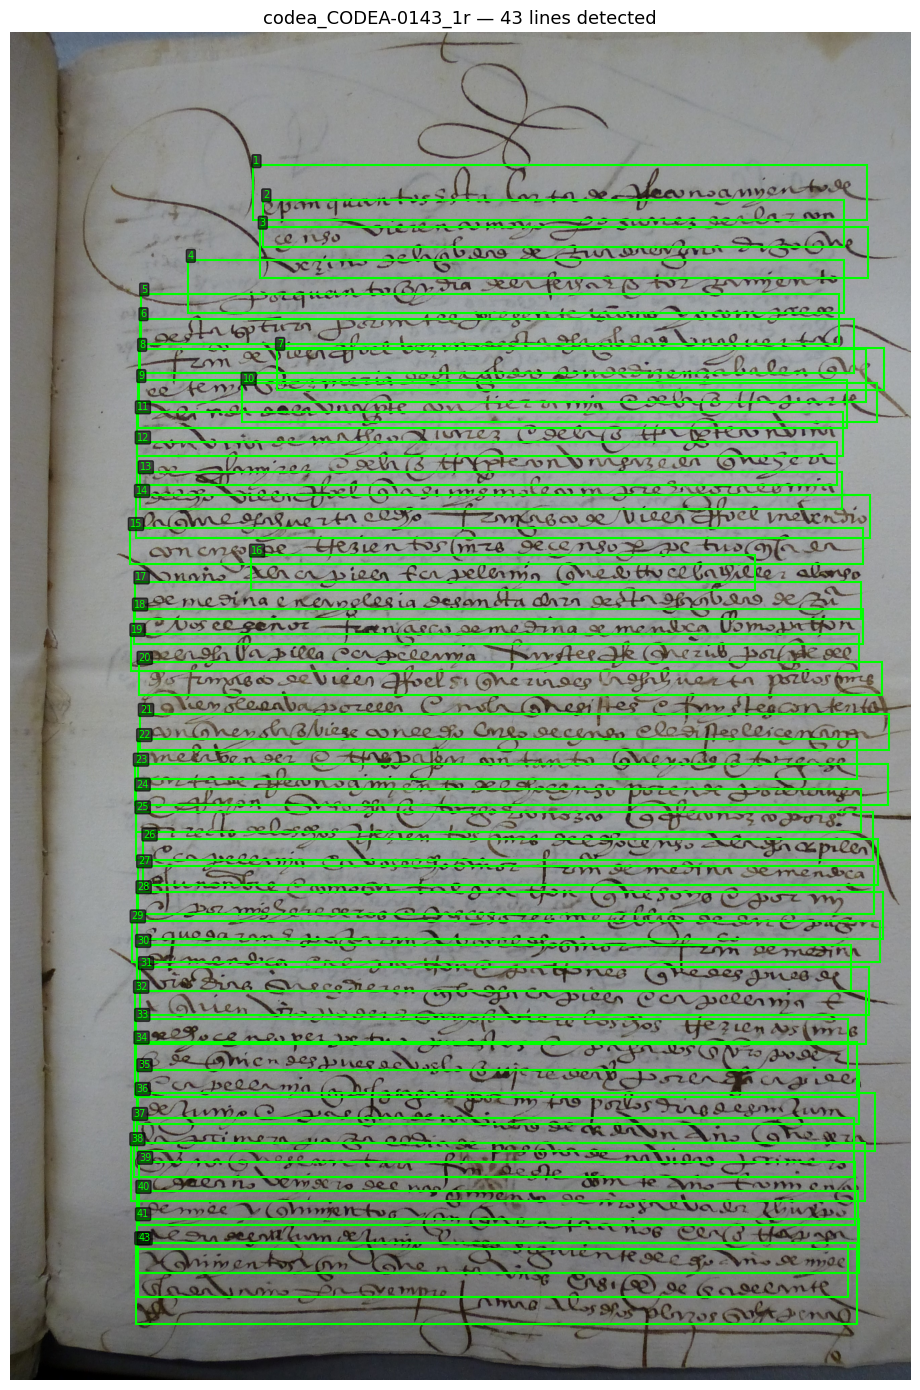

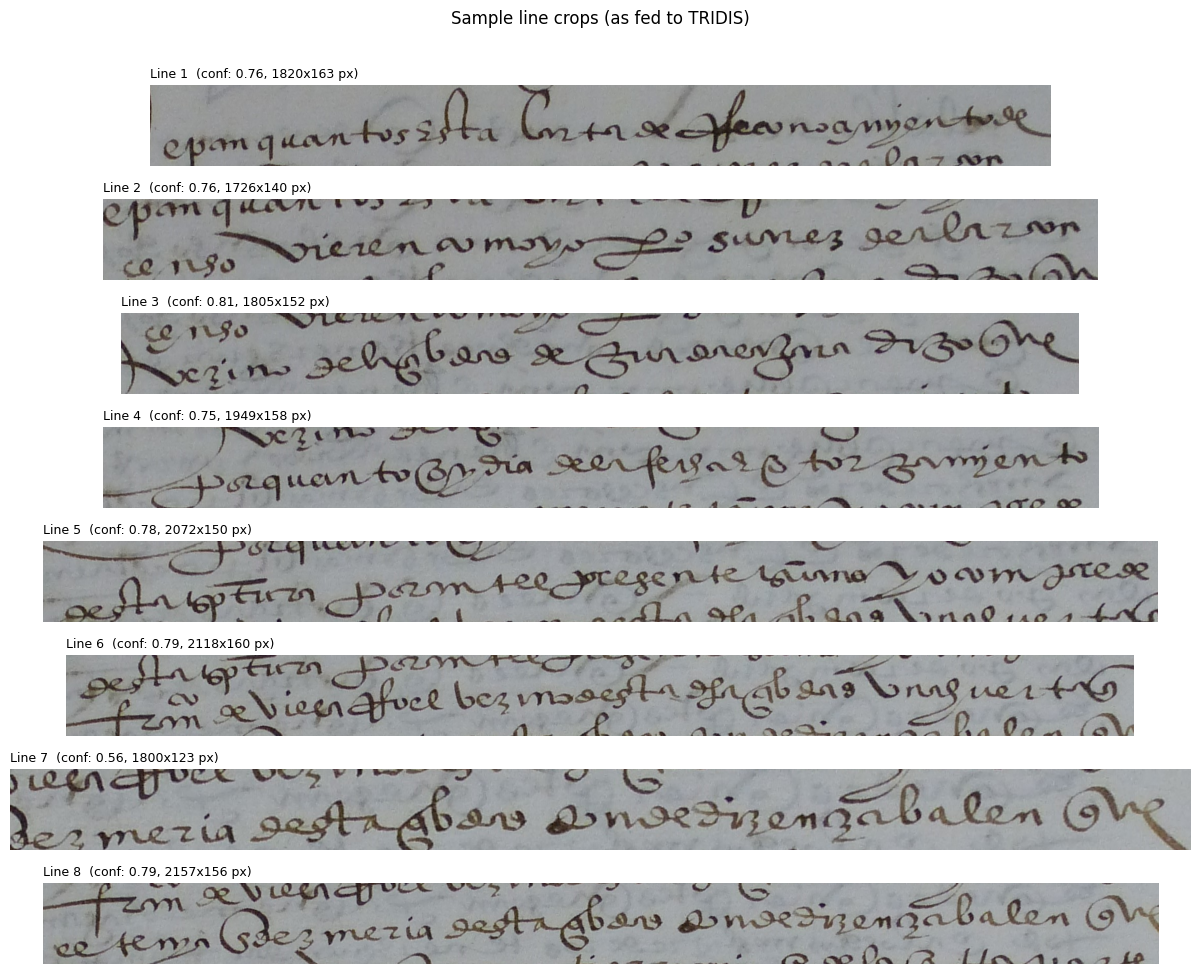

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Use the first page from the manifest
entry = manifest[0]
img_path = Path(IMAGES_DIR) / entry['canonical_name']
image = Image.open(img_path).convert('RGB')
w, h = image.size
print(f"Visualizing: {entry['page_id']} ({w}x{h}, {w*h/1e6:.1f} MP)")

# Run YOLO detection
yolo_results = yolo_model.predict(
    source=image, conf=YOLO_CONF_THRESHOLD, verbose=False
)
boxes = yolo_results[0].boxes

# Filter to text line classes
line_mask = torch.tensor(
    [int(cls.item()) in LINE_CLASS_IDS for cls in boxes.cls],
    dtype=torch.bool
)
line_boxes = boxes.xyxy[line_mask].cpu().numpy()
line_confs = boxes.conf[line_mask].cpu().numpy()

# Sort by y-coordinate for reading order
sort_idx = line_boxes[:, 1].argsort()
line_boxes = line_boxes[sort_idx]
line_confs = line_confs[sort_idx]

print(f'Detected {len(line_boxes)} text lines '
      f'(conf: {line_confs.min():.2f}-{line_confs.max():.2f})')

# --- Plot 1: Full page with bounding boxes ---
fig, ax = plt.subplots(1, 1, figsize=(10, 14))
ax.imshow(image)
for j, (box, conf) in enumerate(zip(line_boxes, line_confs)):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=1.5, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, f'{j+1}', fontsize=7, color='lime',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
ax.set_title(f"{entry['page_id']} — {len(line_boxes)} lines detected", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

# --- Plot 2: Sample line crops ---
n_samples = min(8, len(line_boxes))
fig, axes = plt.subplots(n_samples, 1, figsize=(14, n_samples * 1.2))
if n_samples == 1:
    axes = [axes]
for j in range(n_samples):
    x1, y1, x2, y2 = line_boxes[j].astype(int)
    crop = image.crop((x1, y1, x2, y2))
    axes[j].imshow(crop)
    axes[j].set_title(
        f'Line {j+1}  (conf: {line_confs[j]:.2f}, {x2-x1}x{y2-y1} px)',
        fontsize=9, loc='left'
    )
    axes[j].axis('off')
plt.suptitle('Sample line crops (as fed to TRIDIS)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

torch.cuda.empty_cache()

## 5. Transcribe Pages

For each manuscript page, the pipeline executes five steps:

1. **YOLO detection** — run BigLAM YOLO on the full-resolution page image to detect
   all layout elements.
2. **Filter to text lines** — keep only `DefaultLine` and `HeadingLine` classes above
   the confidence threshold (0.3).
3. **Sort by reading order** — sort detected boxes by y-coordinate (top of bounding box)
   to approximate top-to-bottom reading order.
4. **Crop & transcribe** — for each text line box, crop the region from the full-res
   image, run it through `TrOCRProcessor` → `tridis_model.generate()`.
5. **Concatenate** — join all line transcriptions with newline separators.

**Edge cases:**
- Zero lines detected → writes `[NO LINES DETECTED]` to the output file.
- Degenerate boxes (width < 10px or height < 5px) → skipped with a warning.

**No prompt needed** — TrOCR models take only image input (no text conditioning),
unlike chat-based VLMs (CHURRO, Qwen3-VL) which require system/user messages.

Generation parameters (`num_beams=3`, `max_length=160`, etc.) are set on the model's
`generation_config` in the cell above — see that cell's parameter table for details.

In [14]:
MIN_LINE_WIDTH = 10
MIN_LINE_HEIGHT = 5

for i, entry in enumerate(manifest):
    page_id = entry['page_id']
    out_path = Path(OUTPUT_DIR) / f'{page_id}_raw.txt'
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f'[{i+1}/{len(manifest)}] {page_id} - SKIP')
        continue

    img_path = Path(IMAGES_DIR) / entry['canonical_name']
    if not img_path.exists():
        print(f'[{i+1}/{len(manifest)}] {page_id} - IMAGE NOT FOUND')
        continue

    try:
        image = Image.open(img_path).convert('RGB')
        w, h = image.size
        print(f'  Image: {w}x{h} ({w*h/1e6:.1f} MP)')

        # --- Stage 1: YOLO line detection ---
        yolo_results = yolo_model.predict(
            source=image, conf=YOLO_CONF_THRESHOLD, verbose=False
        )
        boxes = yolo_results[0].boxes

        # Filter to text line classes only
        line_mask = torch.tensor(
            [int(cls.item()) in LINE_CLASS_IDS for cls in boxes.cls],
            dtype=torch.bool
        )
        line_boxes = boxes.xyxy[line_mask].cpu().numpy()
        line_confs = boxes.conf[line_mask].cpu().numpy()

        if len(line_boxes) == 0:
            out_path.write_text('[NO LINES DETECTED]', encoding='utf-8')
            print(f'[{i+1}/{len(manifest)}] {page_id} - NO LINES DETECTED')
            continue

        # Sort by y-coordinate (top of bbox) for reading order
        sort_idx = line_boxes[:, 1].argsort()
        line_boxes = line_boxes[sort_idx]
        line_confs = line_confs[sort_idx]

        print(f'  Detected {len(line_boxes)} text lines '
              f'(conf: {line_confs.min():.2f}-{line_confs.max():.2f})')

        # --- Stage 2: TRIDIS line-level transcription ---
        line_texts = []
        skipped = 0
        for box in line_boxes:
            x1, y1, x2, y2 = box.astype(int)
            crop_w, crop_h = x2 - x1, y2 - y1

            if crop_w < MIN_LINE_WIDTH or crop_h < MIN_LINE_HEIGHT:
                skipped += 1
                continue

            line_crop = image.crop((x1, y1, x2, y2))
            pixel_values = processor(
                images=line_crop, return_tensors='pt'
            ).pixel_values.to(tridis_model.device)

            with torch.no_grad():
                generated_ids = tridis_model.generate(pixel_values)
            line_text = processor.batch_decode(
                generated_ids, skip_special_tokens=True
            )[0]
            line_texts.append(line_text)

        if skipped > 0:
            print(f'  Skipped {skipped} degenerate boxes')

        text = '\n'.join(line_texts)
        out_path.write_text(text, encoding='utf-8')
        print(f'[{i+1}/{len(manifest)}] {page_id} - '
              f'{len(line_texts)} lines, {len(text)} chars')

    except Exception as e:
        print(f'[{i+1}/{len(manifest)}] {page_id} - ERROR: {e}')

    torch.cuda.empty_cache()

print('\nDone!')

[1/60] codea_CODEA-0143_1r - SKIP
[2/60] codea_CODEA-0143_1v - SKIP
  Image: 2769x3870 (10.7 MP)
  Detected 35 text lines (conf: 0.32-0.82)
[3/60] codea_CODEA-2025_1r - 35 lines, 1287 chars
  Image: 2665x3968 (10.6 MP)
  Detected 56 text lines (conf: 0.43-0.84)
[4/60] codea_CODEA-2025_2r - 56 lines, 1380 chars
  Image: 2783x3828 (10.7 MP)
  Detected 30 text lines (conf: 0.50-0.81)
[5/60] codea_CODEA-2025_3v - 30 lines, 1069 chars
  Image: 3000x4000 (12.0 MP)
  Detected 49 text lines (conf: 0.34-0.78)
[6/60] codea_CODEA-2027_1r - 49 lines, 2651 chars
  Image: 3000x4000 (12.0 MP)
  Detected 32 text lines (conf: 0.30-0.71)
[7/60] codea_CODEA-2027_1v - 32 lines, 2064 chars
  Image: 2553x4090 (10.4 MP)
  Detected 41 text lines (conf: 0.31-0.77)
[8/60] codea_CODEA-2612_1r - 41 lines, 1140 chars
  Image: 2641x4017 (10.6 MP)
  Detected 43 text lines (conf: 0.36-0.80)
[9/60] codea_CODEA-2612_1v - 43 lines, 891 chars
  Image: 2689x4001 (10.8 MP)
  Detected 20 text lines (conf: 0.34-0.65)
[10/60]

## 6. Export Results

All raw transcription files are compressed into a single ZIP archive and offered for
download via `google.colab.files`. The archive mirrors the flat structure of
`OUTPUT_DIR` (`{page_id}_raw.txt` per page), which is the format expected by the
downstream CER/WER evaluation scripts.

In [ ]:
import shutil
shutil.make_archive('/content/tridis_v2_results', 'zip', OUTPUT_DIR)
from google.colab import files
files.download('/content/tridis_v2_results.zip')